# Benchmark

Performance comparison of multiprocessing and MLX implementations.

In [2]:
from matplotlib import pyplot as plt
import mlx.core as mx
import numpy as np
from time import perf_counter_ns

from libssr import par, compute, compute_mlx

if par.get_pool() is None:
    par.start_pool()

colors = [
    [230/255, 159/255, 0/255],
    [86/255, 180/255, 233/255],
    [0/255, 158/255, 115/255]
]

rng = np.random.default_rng(0)

## Verify MLX installation

In [3]:
from libssr.consts import has_mlx
if not has_mlx:
    raise RuntimeError("MLX is not available")

## Define test setup and functions

In [4]:
num_vars = 1
num_steps = 100
sig_figs = 12
test_kwargs = dict(
    incr_sampling=100,
    max_sampling=100,
    err_thresh=1E6  # Force one iteration
)


def generate_data(_sample_size: int):
    return {f'X{i}': np.random.uniform(0.0, 100.0, size=(_sample_size, num_steps)) for i in range(num_vars)}


def test_current(_sample):
    return compute.test_sampling_shared(_sample, **test_kwargs)[0]


def test_mlx(_sample):
    return compute_mlx.test_sampling(_sample, **test_kwargs)[0]


def perf_test_current(_sample):
    start_ns = perf_counter_ns()
    test_current(_sample)
    end_ns = perf_counter_ns()
    return end_ns - start_ns


def perf_test_mlx(_sample):
    start_ns = perf_counter_ns()
    test_mlx(_sample)
    end_ns = perf_counter_ns()
    return end_ns - start_ns

## Compare implementation encodings

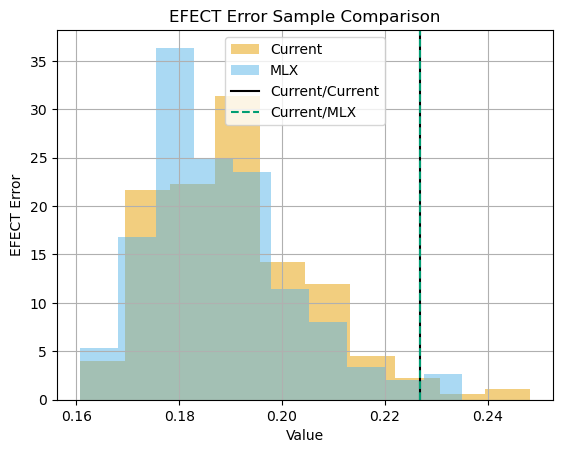

In [5]:
s = generate_data(1000)
es_current = test_current(s)
es_mlx = test_mlx(s)

hs = {k: v[:v.shape[0] // 2, :] for k, v in s.items()}
hs2 = {k: v[v.shape[0] // 2:, :] for k, v in s.items()}

err_compare = 0.0
err_compare2 = 0.0
for var_name, var_values in hs.items():
    for j in range(var_values.shape[1]):
        vj = var_values[:, j]
        vj2 = hs2[var_name][:, j]
        tvals = compute.get_eval_info_times(100, compute.eval_final(vj))
        ecf1 = compute.ecf(vj, tvals)

        err_compare = max(err_compare, 
                          compute.ecf_compare(ecf1, 
                                              compute.ecf(vj2, tvals)))
        err_compare2 = max(err_compare2, 
                           compute.ecf_compare(ecf1, 
                                               compute_mlx.ecf(mx.array(vj2), mx.array(tvals))))

plt.hist(es_current, density=True, alpha=0.5, color=colors[0], label='Current')
plt.hist(es_mlx, density=True, alpha=0.5, color=colors[1], label='MLX')
plt.axvline(x=err_compare, color='black', linestyle='-', label='Current/Current')
plt.axvline(x=err_compare2, color=colors[2], linestyle='--', label='Current/MLX')
plt.xlabel('Value')
plt.ylabel('EFECT Error')
plt.title('EFECT Error Sample Comparison')
plt.legend()
_ = plt.grid(True)

## Define performance test

In [6]:
sz_test = [int(10 ** (i / 2) // 2 * 2) for i in range(2, 9)]
sz_test

[10, 30, 100, 316, 1000, 3162, 10000]

## Do performance test

In [7]:
perf_res_mlx = []
perf_res_cur = []
for i, sz in enumerate(sz_test):
    print(f"Testing size {sz} ({i + 1}/{len(sz_test)})...")
    data = generate_data(sz)

    print('\tMLX...')
    perf_res_mlx.append(perf_test_mlx(data))
    print('\tCurrent...')
    perf_res_cur.append(perf_test_current(data))

Testing size 10 (1/7)...
	MLX...
	Current...
Testing size 30 (2/7)...
	MLX...
	Current...
Testing size 100 (3/7)...
	MLX...
	Current...
Testing size 316 (4/7)...
	MLX...
	Current...
Testing size 1000 (5/7)...
	MLX...
	Current...
Testing size 3162 (6/7)...
	MLX...
	Current...
Testing size 10000 (7/7)...
	MLX...
	Current...


## Report performance test results

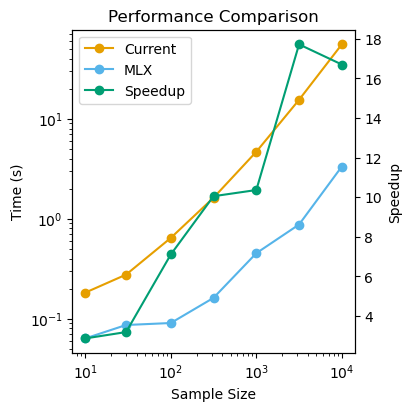

In [8]:
fig, ax = plt.subplots(1, 1, layout='compressed', figsize=(4, 4))
l1 = ax.plot(sz_test, np.array(perf_res_cur) / 1E9, 'o-', color=colors[0], label='Current')[0]
l2 = ax.plot(sz_test, np.array(perf_res_mlx) / 1E9, 'o-', color=colors[1], label='MLX')[0]
ax.set_xlabel('Sample Size')
ax.set_ylabel('Time (s)')
ax.set_title('Performance Comparison')
ax.set_xscale('log')
ax.set_yscale('log')

ax2 = ax.twinx()
l3 = ax2.plot(sz_test, np.array(perf_res_cur) / np.array(perf_res_mlx), 'o-', color=colors[2], label='Speedup')[0]
ax2.set_xscale('log')
ax2.set_xlabel('Sample Size')
ax2.set_ylabel('Speedup')

_ = ax.legend(handles=[l1, l2, l3])